# Net3 端到端流程：零阶/停留时间 → 正向 → 加噪声 → 反演

**目标**：先不用真实数据，在 Net3 上把整条项目流程走通（老师 2026-06-12 路线图）。

| 步 | 主题 | 学到的东西 | 对应老师 6.12 |
|---|------|-----------|--------------|
| 0 | 零阶衰减 + 停留时间（建直觉） | 零阶下浓度随水龄线性下降 | `zero order decay`；`0-order → time/residence` |
| 1 | 正向 Forward（kw 随管材异质）→ 生成真值 | 给定 C₀ + 按管材的 kw → 节点浓度真值 | ① 正向；`kw=f(material)`；`20% old CI` |
| 2 | 加随机噪声 | 真值叠加传感器噪声当"测量" | ③ `+ random noise`；`noisy sensor` |
| 3 | 反演 Inverse（恢复多个 kw） | 用带噪声测量倒推每种管材的 kw | ③ `inverse problem`；② `pipe groups` |
| 4 | 闭环验证 | 正向→加噪声→反演→恢复，重复多次报告误差 | 整条流程"走通" |

> **怎么用这个 notebook** —— 每一步分 3 块：
> 1. **题目**（markdown：背景 + 学习目标 + 任务 + 提示）
> 2. **代码骨架**（含 `# TODO`，你来填）
> 3. **思考**（markdown：做完后用一两句话总结发现）
>
> ⚠️ **画图约定**：图内文字（标题 / 轴标签 / 图例）一律用**英文**。
>
> 配套：`../README.md`、`../plan1.md`、`meetings/meeting-老师/6.12/进度对照与待办.md`


## Setup（环境 + 复用并扩展核心函数）

复用 `02_exercises.ipynb` 的 `simulate_chlorine()`，并**新增 `bulk_order / wall_order` 参数**，
这样同一个函数既能跑一阶（`order=1`）也能跑零阶（`order=0`，老师 6.12 提到的 `zero order`）。
逐管的 `kw`（按管材）通过 `pre_run` 钩子设置（见第 1 步）。


In [9]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import networkx as nx
import wntr

PRACTICE_INP = os.path.join(os.path.dirname(wntr.__file__), 'library', 'networks', 'Net3.inp')
MONITOR_NODES = ['10', '15', '20', '35', '40', '60']
INLET_CHLORINE_MGL = 1.0
SECONDS_PER_DAY = 24 * 3600

def per_day_to_per_second(v):
    return v / SECONDS_PER_DAY

def simulate_chlorine(kb_per_day, kw_per_day,
                      monitor_nodes=None,
                      inp_file=PRACTICE_INP,
                      inlet_mgl=INLET_CHLORINE_MGL,
                      duration_hours=48,
                      bulk_order=1,      # 1 = 一阶, 0 = 零阶 (老师 6.12)
                      wall_order=1,
                      pre_run=None):
    """
    单次余氯仿真。
    bulk_order / wall_order : 反应级数 (1=一阶, 0=零阶)。
    pre_run : 可选 callable(wn) -> None，仿真前修改 wn（逐管设 kw / 改管径 / 加 source 等）。
    返回 : DataFrame (index=hours, cols=监测点 ID, 单位 mg/L)
    """
    if monitor_nodes is None:
        monitor_nodes = MONITOR_NODES
    wn = wntr.network.WaterNetworkModel(inp_file)
    wn.options.time.duration           = duration_hours * 3600
    wn.options.time.hydraulic_timestep = 3600
    wn.options.time.report_timestep    = 3600
    wn.options.time.quality_timestep   = 300
    wn.options.quality.parameter     = 'CHEMICAL'
    wn.options.quality.chemical_name = 'Chlorine'
    wn.options.quality.inpfile_units = 'mg/L'
    wn.options.reaction.bulk_order = bulk_order
    wn.options.reaction.wall_order = wall_order
    wn.options.reaction.bulk_coeff = per_day_to_per_second(kb_per_day)
    wn.options.reaction.wall_coeff = per_day_to_per_second(kw_per_day)
    for r in wn.reservoir_name_list:
        wn.get_node(r).initial_quality = inlet_mgl

    if pre_run is not None:
        pre_run(wn)

    res = wntr.sim.EpanetSimulator(wn).run_sim()
    q = res.node['quality'][monitor_nodes]
    q.index = q.index / 3600.0
    q.index.name = 'hours'
    return q

def simulate_age(inp_file=PRACTICE_INP, monitor_nodes=None, duration_hours=72):
    """返回各监测点水龄 (小时) 的时间序列（quality.parameter='AGE'）。"""
    if monitor_nodes is None:
        monitor_nodes = MONITOR_NODES
    wn = wntr.network.WaterNetworkModel(inp_file)
    wn.options.time.duration        = duration_hours * 3600
    wn.options.time.report_timestep = 3600
    wn.options.quality.parameter = 'AGE'
    res = wntr.sim.EpanetSimulator(wn).run_sim()
    age = res.node['quality'][monitor_nodes] / 3600.0   # 秒 -> 小时
    age.index = age.index / 3600.0
    age.index.name = 'hours'
    return age

# Sanity check（一阶）
ts0 = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1)
print('shape:', ts0.shape)
ts0.tail(3).round(3)


shape: (49, 6)


name,10,15,20,35,40,60
hours,,,,,,
46.0,0.863,0.266,0.100,0.685,0.164,1.000
47.0,0.845,0.081,0.832,0.650,0.164,0.998
48.0,0.828,0.079,0.831,0.713,0.161,0.998


---
## 第 0 步 · 零阶衰减 + 停留时间（建直觉）

> **老师 6.12**：`zero order decay`（右侧待办第一条）；`0-order decay → time / residence`。
> 先用最简单的零阶 + 水龄建立"浓度 ↔ 停留时间 ↔ 管长"的直觉，再做后面的管材异质 kw / 反演。

### 中文背景

- **零阶衰减**：速率为常数，与浓度无关。

  ```
  dC/dt = -k₀     →     C(τ) = C₀ - k₀·τ   (到 0 截断)
  ```

  其中 `τ` = 水龄 / 停留时间（水从源头流到该节点要多久，≈ 管长 ÷ 流速）。

- **关键**：零阶下浓度下降 `ΔC = k₀·τ` 是**停留时间的线性函数** ——
  节点浓度直接由"水流到它要多久"决定。所以先看零阶最容易懂。
- 对比一阶 `C = C₀·exp(-k·τ)`（指数），零阶是直线，更适合建直觉。
- **水龄**用 EPANET 直接算：`quality.parameter = 'AGE'`（Setup 里的 `simulate_age()`）。

### 学习目标

1. 跑零阶正向，拿到 6 个监测点浓度。
2. 算各节点水龄 τ。
3. 画 **浓度 vs 水龄** 散点，看零阶下是否近似一条直线（验证 `decay ~ residence time`）。

### 任务（本步是 demo，已给好可直接运行）

1. 用 `simulate_chlorine(..., bulk_order=0, wall_order=0)` 跑零阶（这里只放 bulk，`kw=0`，故事最干净）。
2. 用 `simulate_age()` 拿各节点水龄。
3. 把"节点稳态浓度"对"节点水龄"画散点。

### 提示

- 零阶系数量纲是 mg/L per day（和一阶不同），`k₀ ≈ -0.3` 左右曲线落在合理范围。
- 稳态值用最后 24 h 均值：`ts.iloc[-24:].mean()`。


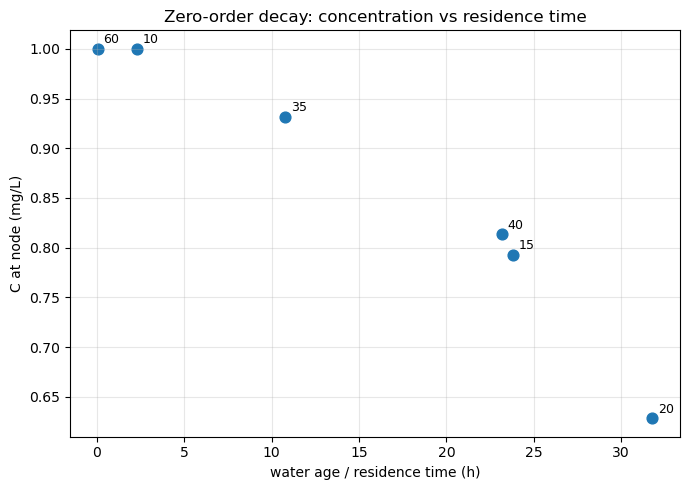

,water_age_h,C_mgL
name,,
60,0.050000,1.000
10,2.290000,1.000
35,10.790000,0.932
40,23.180000,0.813
15,23.840000,0.793
20,31.790001,0.628


In [10]:
# === 零阶衰减 + 停留时间（demo）===

# 1) 零阶正向（老师 6.12 第一条）：只放 bulk 零阶，kw=0，浓度~水龄关系最干净
ts_zero = simulate_chlorine(kb_per_day=-0.3, kw_per_day=0.0,
                            bulk_order=0, wall_order=0, duration_hours=72)

# 2) 各节点水龄（停留时间）
age = simulate_age(duration_hours=72)

# 3) 稳态值（最后 24h 均值）
c_mean   = ts_zero.iloc[-24:].mean()
age_mean = age.iloc[-24:].mean()

# 4) 浓度 vs 水龄 散点（零阶下应近似一条下降直线）
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(age_mean, c_mean, s=60)
for n in MONITOR_NODES:
    ax.annotate(n, (age_mean[n], c_mean[n]), xytext=(4, 4),
                textcoords='offset points', fontsize=9)
ax.set_xlabel('water age / residence time (h)')
ax.set_ylabel('C at node (mg/L)')
ax.set_title('Zero-order decay: concentration vs residence time')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

pd.DataFrame({'water_age_h': age_mean.round(2), 'C_mgL': c_mean.round(3)}).sort_values('water_age_h')


### ✏️ 你的发现

1. **散点图**：6 个监测点大致落在一条**下降直线**上（线性拟合 `C ≈ 1.03 − 0.011·τ`，`τ` 单位 h）。
   不是完美直线——**node 20** 因 tank + 日用水波动，偏离略大。
2. **水龄 vs 浓度**：末 24 h 平均水龄最高的是 **node 20**（约 **32 h**），浓度也最低（约 **0.63 mg/L**）；
   **node 60**（≈0 h）和 **node 10**（≈2 h）靠近水源，浓度仍 ≈ **1.0 mg/L**。
3. 印证零阶关系 **`C ≈ C₀ − k₀·τ`**：衰减主要由**停留时间**决定，与一阶 `kw/kb` 无关。
   这也说明：用零阶扫一遍水龄，可以先定仿真时长/warm-up，再进一阶 + 异质 `kw` 的正向。

---


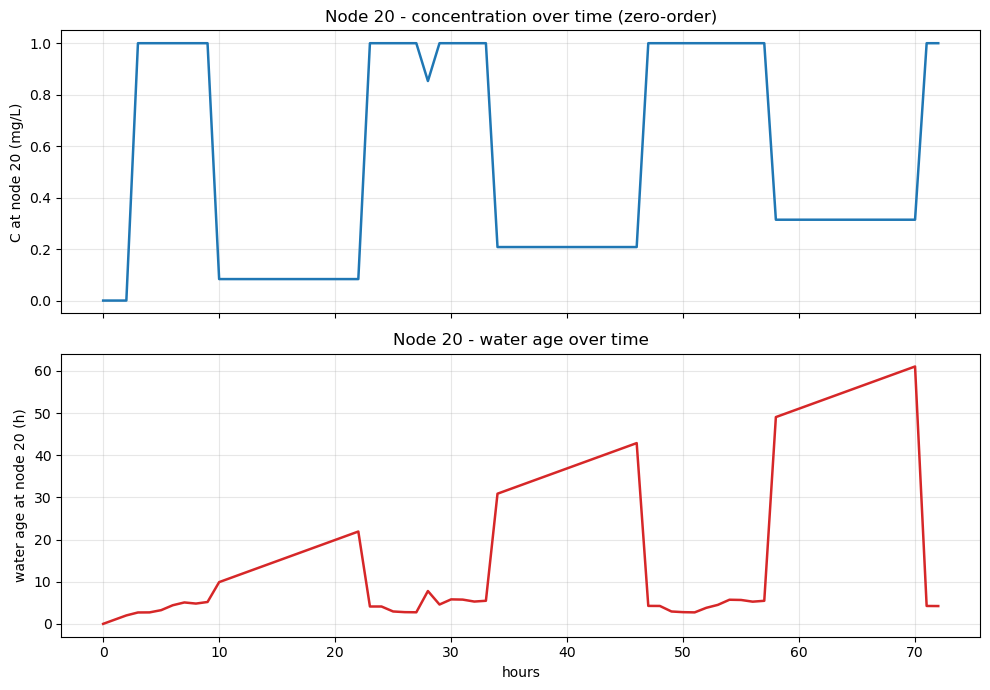

In [11]:
# === 节点浓度随时间的波动（复用第 0 步的 ts_zero / age）===
# 节点浓度和水龄都不是常数：会随每日用水 + 水箱动态摆动。
# 这也是为什么稳态要取最后 24h 的均值（把波动压成一个代表值）。
# 想看别的节点就改 probe。

probe = '20'
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot(ts_zero.index, ts_zero[probe], color='tab:blue', lw=1.8)
ax1.set_ylabel(f'C at node {probe} (mg/L)')
ax1.set_title(f'Node {probe} - concentration over time (zero-order)')
ax1.grid(alpha=0.3)

ax2.plot(age.index, age[probe], color='tab:red', lw=1.8)
ax2.set_ylabel(f'water age at node {probe} (h)')
ax2.set_xlabel('hours')
ax2.set_title(f'Node {probe} - water age over time')
ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## 第 1 步 · 正向模拟 Forward：kw 随管材异质 → 生成真值

> **老师 6.12**：① 正向（`C₀, kw → C₁, C₂, C₃`）；`kw = f(pipe material)`；`pipe groups = old / CI old`。
> 关键：**生成真值时就要用"不同管材的 kw"**——这是后面加噪声、反演的输入。

### 中文背景

- **正向问题**：已知参数（`k_b` + 各管壁的 `k_w`）→ 模拟出各节点浓度真值。
- **管壁衰减随管材异质**：老管（如老铸铁 CI）管壁反应强（`k_w` 大），新管（塑料）弱。
  EPANET 里可以**逐管设 `pipe.wall_coeff`**，覆盖全局值。
- Net3 没有真实管材数据，所以我们**假设一片连续区域（成片老管 DMA）**当老铸铁，其余当新管——比随机撒 20% 老管更接近真实分区，信号也更 localized。
- `k_b`（本体衰减）当作**已知固定**（bottle test），不参与反演——只反演 `k_w`。

### 学习目标

1. 用 networkx 从 seed 节点出发，选 **n_hops 步内连成一片**的管当 `old_CI`。
2. 画**老管空间分布图** + **成片老管引起的余氯变化**（对比全新管 baseline）。
3. 得到 6 个监测点的**真值浓度时间序列** `truth`。

### 任务

1. 看 `old_pipes_cluster()` 怎么选成片老管。
2. 跑通 `truth`，检查 node 15 附近是否有明显 drop。
3. 后面第 2/3 步将基于这里的 `truth` 和 `MATERIAL` 继续。


pipes: 117 | old_CI cluster: 6 (5.1%)

Mean C last 24 h (mg/L):
      all_new  old_DMA   drop
name                         
10      0.955    0.955  0.000
15      0.540    0.282  0.258
20      0.483    0.483  0.000
35      0.775    0.775  0.000
40      0.600    0.600  0.000
60      0.998    0.998  0.000
max drop: 0.258 mg/L at node 15


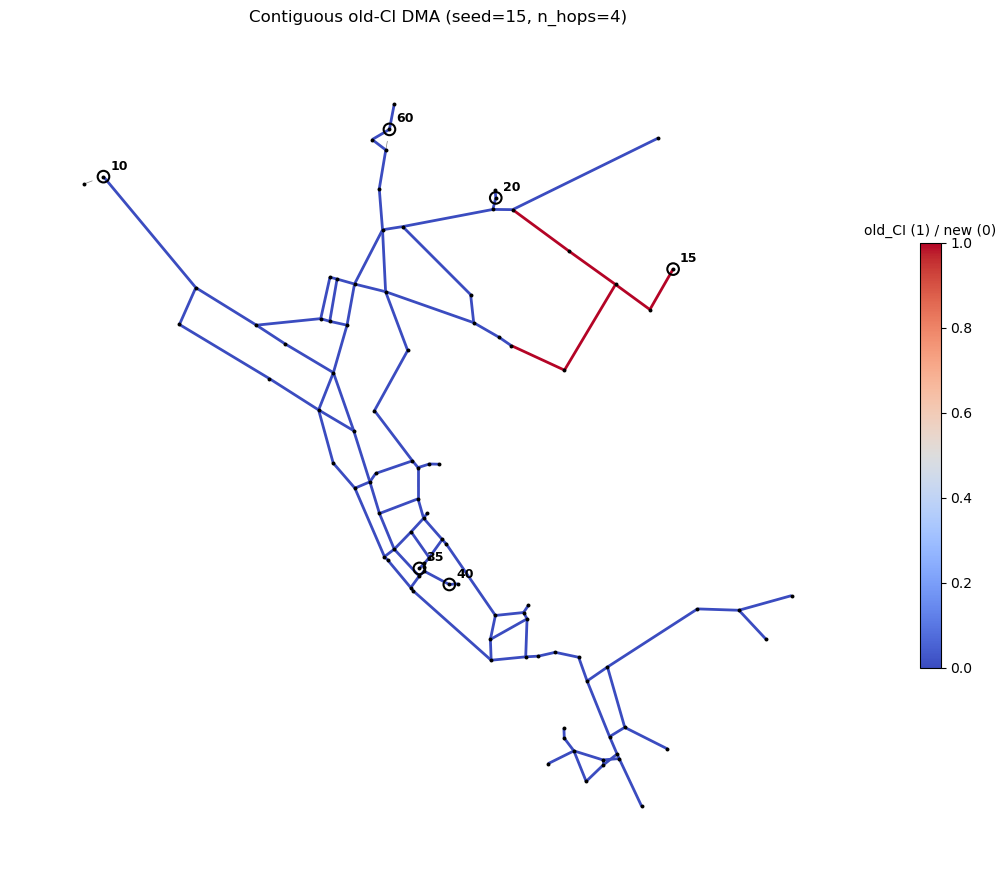

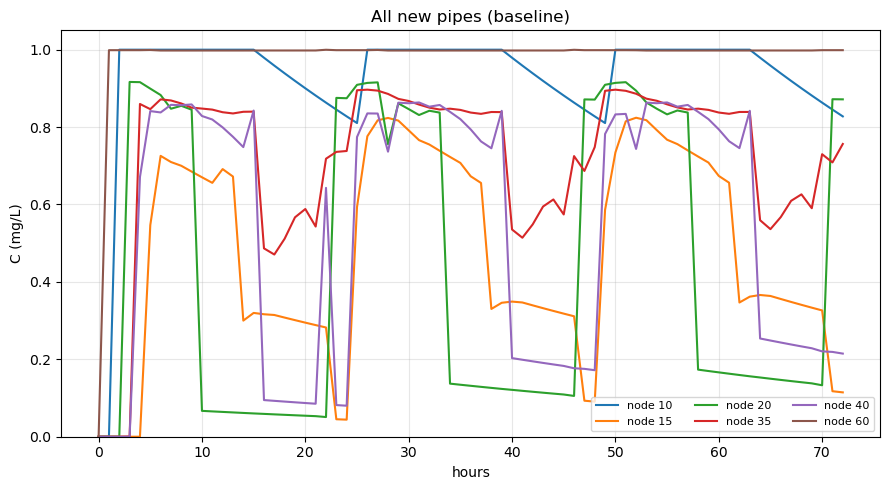

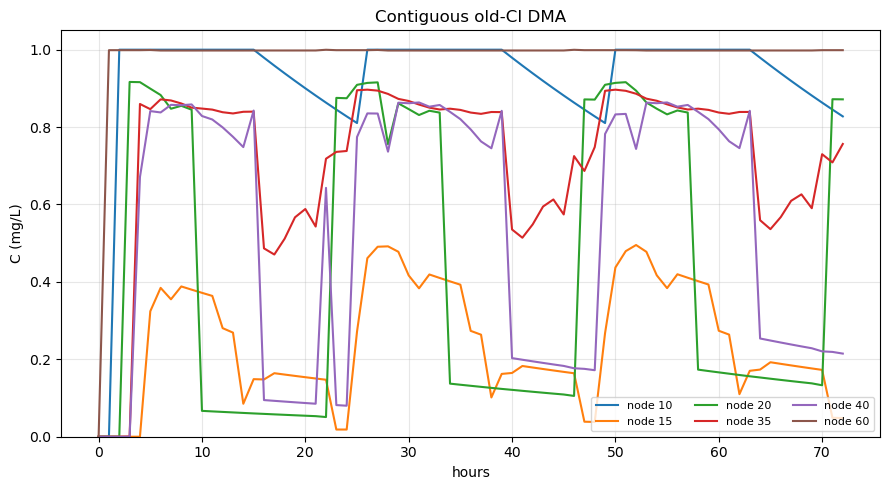

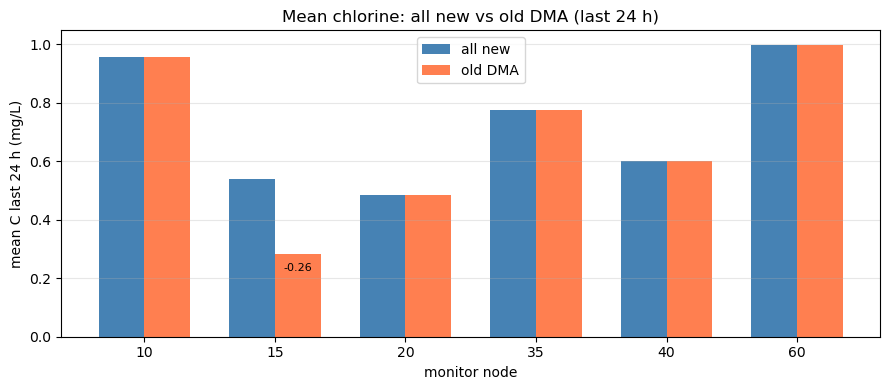

name,10,15,20,35,40,60
hours,,,,,,
70.0,0.863,0.173,0.133,0.730,0.221,0.999
71.0,0.845,0.049,0.872,0.709,0.219,0.999
72.0,0.828,0.048,0.872,0.756,0.215,0.999


In [12]:
# === 真值生成：成片老管 DMA（按管材异质 kw）===

DURATION_H      = 72       # 仿真时长(小时)
KB_FIXED        = -0.5     # bulk decay，已知固定 (/day)，不反演
KW_OLD_TRUE     = -1.0     # old cast iron: strong wall decay (/day)
KW_NEW_TRUE     = -0.05    # new plastic:   weak  wall decay (/day)
CLUSTER_SEED    = '15'     # 从 kw 敏感监测点 15 出发选一片老管
CLUSTER_N_HOPS  = 4        # 沿管网走 4 跳以内的管


def old_pipes_cluster(inp_file=PRACTICE_INP, seed=CLUSTER_SEED, n_hops=CLUSTER_N_HOPS):
    """成片老管：seed 节点 n_hops 步内、两端都在该区域的管标为 old_CI。"""
    wn = wntr.network.WaterNetworkModel(inp_file)
    G = wn.to_graph().to_undirected()
    near = set(nx.single_source_shortest_path_length(G, seed, cutoff=n_hops).keys())
    old = set()
    for p in wn.pipe_name_list:
        lk = wn.get_link(p)
        if lk.start_node_name in near and lk.end_node_name in near:
            old.add(p)
    return old


def assign_materials_cluster(inp_file=PRACTICE_INP, seed=CLUSTER_SEED, n_hops=CLUSTER_N_HOPS):
    wn = wntr.network.WaterNetworkModel(inp_file)
    old = old_pipes_cluster(inp_file, seed=seed, n_hops=n_hops)
    return {p: ('old_CI' if p in old else 'new') for p in wn.pipe_name_list}


MATERIAL = assign_materials_cluster()
OLD_PIPES = {p for p, m in MATERIAL.items() if m == 'old_CI'}
n_pipes = len(MATERIAL)
print(f'pipes: {n_pipes} | old_CI cluster: {len(OLD_PIPES)} ({100*len(OLD_PIPES)/n_pipes:.1f}%)')


def make_kw_hook(kw_old, kw_new, material=None):
    """逐管设 wall_coeff；material 默认用全局 MATERIAL。"""
    mat = MATERIAL if material is None else material
    def _hook(wn):
        for p in wn.pipe_name_list:
            kw = kw_old if mat[p] == 'old_CI' else kw_new
            wn.get_link(p).wall_coeff = per_day_to_per_second(kw)
    return _hook


# --- 正向：成片老管真值 ---
truth = simulate_chlorine(kb_per_day=KB_FIXED, kw_per_day=0.0,
                          pre_run=make_kw_hook(KW_OLD_TRUE, KW_NEW_TRUE),
                          duration_hours=DURATION_H)

# --- baseline：全网新管（对比用）---
MATERIAL_ALL_NEW = {p: 'new' for p in MATERIAL}
truth_all_new = simulate_chlorine(kb_per_day=KB_FIXED, kw_per_day=0.0,
                                  pre_run=make_kw_hook(KW_OLD_TRUE, KW_NEW_TRUE,
                                                       material=MATERIAL_ALL_NEW),
                                  duration_hours=DURATION_H)

# 末 24 h 平均（稳态段）
mean_dma = truth.iloc[-24:].mean()
mean_new = truth_all_new.iloc[-24:].mean()
drop = mean_new - mean_dma
print('\nMean C last 24 h (mg/L):')
print(pd.DataFrame({'all_new': mean_new.round(3), 'old_DMA': mean_dma.round(3),
                    'drop': drop.round(3)}))
print(f'max drop: {drop.max():.3f} mg/L at node {drop.idxmax()}')

# --- 图 1：成片老管空间分布 ---
wn_map = wntr.network.WaterNetworkModel(PRACTICE_INP)
link_old = {p: (1.0 if p in OLD_PIPES else 0.0) for p in wn_map.pipe_name_list}
fig, ax = plt.subplots(figsize=(11, 9))
wntr.graphics.plot_network(
    wn_map, link_attribute=link_old, link_width=2.0,
    link_cmap=plt.cm.coolwarm, link_colorbar_label='old_CI (1) / new (0)',
    node_size=8,
    title=f"Contiguous old-CI DMA (seed={CLUSTER_SEED}, n_hops={CLUSTER_N_HOPS})",
    ax=ax, show_plot=False,
)
for n in MONITOR_NODES:
    x, y = wn_map.get_node(n).coordinates
    ax.scatter([x], [y], s=70, facecolors='none', edgecolors='black', linewidths=1.5, zorder=6)
    ax.annotate(n, (x, y), xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()

# --- 图 2：全新管余氯时间序列（单独一张图）---
ylim = (0, 1.05)
fig, ax = plt.subplots(figsize=(9, 5))
for n in MONITOR_NODES:
    ax.plot(truth_all_new.index, truth_all_new[n], label=f'node {n}')
ax.set_xlabel('hours'); ax.set_ylabel('C (mg/L)'); ax.set_ylim(ylim)
ax.set_title('All new pipes (baseline)')
ax.legend(ncol=3, fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# --- 图 3：成片老管余氯时间序列（单独一张图）---
fig, ax = plt.subplots(figsize=(9, 5))
for n in MONITOR_NODES:
    ax.plot(truth.index, truth[n], label=f'node {n}')
ax.set_xlabel('hours'); ax.set_ylabel('C (mg/L)'); ax.set_ylim(ylim)
ax.set_title('Contiguous old-CI DMA')
ax.legend(ncol=3, fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# --- 图 4：末 24 h 平均浓度对比（单独一张图）---
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(MONITOR_NODES))
w = 0.35
ax.bar(x - w/2, mean_new.values, w, label='all new', color='steelblue')
ax.bar(x + w/2, mean_dma.values, w, label='old DMA', color='coral')
ax.set_xticks(x); ax.set_xticklabels(MONITOR_NODES)
ax.set_xlabel('monitor node'); ax.set_ylabel('mean C last 24 h (mg/L)')
ax.set_title('Mean chlorine: all new vs old DMA (last 24 h)')
for i, d in enumerate(drop.values):
    if d > 0.01:
        ax.annotate(f'-{d:.2f}', (i + w/2, mean_dma.values[i]),
                    xytext=(0, -12), textcoords='offset points', ha='center', fontsize=8)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

truth.tail(3).round(3)


### ✏️ 你的发现

1. **成片老管**：从 node **15** 出发、**4 跳**内共 **6 根管**（117 根的 **5%**），
   形成一片连续的 old_CI DMA（不是随机撒 20%）。
2. **谁受影响**：只有老管**下游**的 **node 15** 浓度明显下降——
   末 24 h 均值从 **0.540 → 0.282 mg/L**（**drop ≈ 0.26 mg/L**）；
   **10 / 20 / 35 / 40 / 60** 与「全网新管」baseline **完全一致**（drop = 0）。
3. **灵敏度**：对 **`kw_old` 最敏感的是 node 15**（唯一经过那片老管的监测点）；
   这次实验里 **`kw_new` 全网 uniform**，6 个点之间没有 differential 信号——
   反演时主要靠 node 15 拉 `kw_old`，`kw_new` 需要更多监测点或更强 contrast 才更好辨识。
4. 对比随机 20% 老管：成片版用**更少的老管**打出**更 localized、更大的**信号，
   更适合后面加噪声 + 反演 demo。



---
## 第 2 步 · 给观测加随机噪声

> **老师 6.12**：③ `C₁, C₂, C₃ + random noise → measurement`；`mg/L → ppm → sensor`（读数 noisy）。

### 中文背景

真实传感器读数不是干净的模拟值，而是带误差的。我们把**第 1 步生成的真值 `truth`（异质 kw）**
叠加随机噪声，造出"假测量"——这样我们**知道真实参数**，方便第 3、4 步验证反演对不对。

- 绝对误差（高斯）：

  ```
  C_meas(t) = C_sim(t) + ε,   ε ~ Normal(0, σ²)
  ```

- （可选）比例误差：`ε ~ Normal(0, (r·C_sim)²)`，模拟"满量程百分比"型传感器。

### 学习目标

1. 学会用可复现的随机数生成器造测量噪声。
2. 理解为什么浓度要 clip 到 `≥ 0`（物理约束）。

### 任务

1. 用第 1 步的真值 `truth`。
2. 设 `σ ≈ 0.02 mg/L`，加高斯噪声得到 `noisy`。
3. 把负值裁到 0。
4. 选一个节点，画 `truth`（线）对比 `noisy`（散点）。

### 提示

- 用 `rng = np.random.default_rng(42)` 保证可复现。
- 噪声形状要和数据一致：`rng.normal(0, sigma, size=truth.shape)`。
- DataFrame 有 `.clip(lower=0)`。


σ = 0.02 mg/L | RMSE(noise) = 0.0189 mg/L
points clipped to 0: 10 / 438


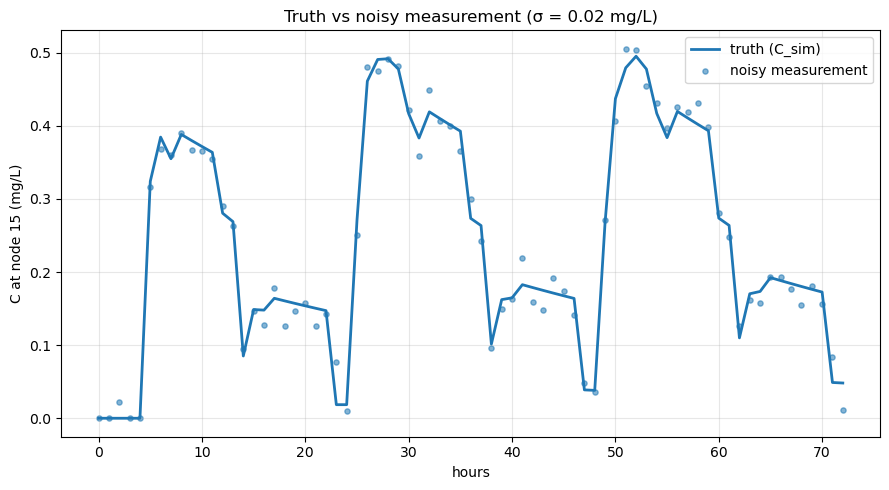


Relative noise σ/mean(C) last 24 h (%):
name
10    2.1
15    7.1
20    4.1
35    2.6
40    3.3
60    2.0


In [13]:
# === 加随机噪声：真值 → 假测量 ===

rng = np.random.default_rng(42)

# truth 来自第 1 步（按管材异质 kw 生成的真值）
SIGMA_ABS = 0.02             # 传感器绝对误差 (mg/L)

# 1) 生成与 truth 同形状的高斯噪声并叠加
raw = truth + rng.normal(0, SIGMA_ABS, size=truth.shape)
n_clip = int((raw < 0).sum().sum())

# 2) 浓度不能为负，clip 到 >= 0
noisy = raw.clip(lower=0)
obs = noisy                    # 第 3 步反演用这个名字

noise = noisy - truth
print(f'σ = {SIGMA_ABS} mg/L | RMSE(noise) = {np.sqrt((noise**2).mean().mean()):.4f} mg/L')
print(f'points clipped to 0: {n_clip} / {raw.size}')

# 3) 画 truth vs noisy（node 15 = 成片老管信号最强的点）
probe = '15'
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(truth.index, truth[probe], lw=2, label='truth (C_sim)')
ax.scatter(truth.index, noisy[probe], s=14, alpha=0.55, label='noisy measurement')
ax.set_xlabel('hours'); ax.set_ylabel(f'C at node {probe} (mg/L)')
ax.set_title(f'Truth vs noisy measurement (σ = {SIGMA_ABS} mg/L)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 各监测点末 24 h：相对噪声 ≈ σ / mean(C)
c24 = truth.iloc[-24:].mean()
rel_pct = 100 * SIGMA_ABS / c24
print('\nRelative noise σ/mean(C) last 24 h (%):')
print(rel_pct.round(1).to_string())


### ✏️ 你的发现

1. **`σ = 0.02 mg/L`** 时，噪声 RMSE ≈ **0.019 mg/L**，与设定一致；全网共 **10** 个时空点被 clip 到 0（主要在 warmup 低浓度段）。
2. **相对噪声** `σ / mean(C)`（末 24 h）：高浓度点 **10 / 60** 仅 **~2%**；
   **node 15**（均值 ≈ **0.28 mg/L**）约 **~7%**——浓度越低，**同样绝对误差对应的相对误差越大**。
3. node 15 上散点围绕 truth 曲线抖动，但 **0.26 mg/L 的老管信号仍远大于 σ**，说明这点对反演 `kw_old` 仍有信息。
4. 对后面反演的提示：低浓度点应**加权**（或按比例误差模型），否则 SSE 会被高浓度节点（10、60）主导。



---
## 第 3 步 · 反演 Inverse：恢复多个 kw（每种管材一个）

> **老师 6.12**：③ `inverse problem`——用"测量值"倒推参数；② `pipe groups`（每组一个 kw）。

### 中文背景

反演 = 已知**测量**，倒推**参数**。这次真值是用**两种管材的 kw**生成的，
所以反演的未知数是 **`(kw_old, kw_new)` 两个**（`k_b` 固定，不反演）。
做法和 02 练习 5 一样是网格搜索，只是网格的两个轴从 `(k_b, k_w)` 换成 `(kw_old, kw_new)`。

**目标函数**（误差平方和）：

```
SSE(kw_old, kw_new) = Σ (C_sim − C_meas)²
```

### 学习目标

1. 在带噪声观测下反演 **两个** 管材的 kw。
2. 看二维误差面：`kw_old` / `kw_new` 各自好不好辨识（哪个管材的信息更足）。

### 任务

1. 用第 2 步的 `noisy` 当观测 `obs`，去掉 warmup（前 24 h）。
2. 在 `kw_old ∈ [-1, 0] × kw_new ∈ [-0.3, 0]` 建 9×9 网格（真值 `kw_old=-1.0` 落在网格边上）。
3. 每格用 `make_kw_hook(kw_old, kw_new)` 跑正向，算 SSE。
4. 画 `log₁₀(SSE)` 热力图，标真值 `(KW_OLD_TRUE, KW_NEW_TRUE)` 与最优格。

### 提示

- 正向：`simulate_chlorine(kb_per_day=KB_FIXED, kw_per_day=0.0, pre_run=make_kw_hook(kwo, kwn), duration_hours=DURATION_H)`。
- `((sim - obs) ** 2).sum().sum()` 把所有节点所有时刻的平方误差加总成标量。
- 真值是第 1 步的 `(KW_OLD_TRUE, KW_NEW_TRUE) = (-1.0, -0.05)`。


网格搜索中（二维 kw_old × kw_new）...
  行 1/9 完成
  行 2/9 完成
  行 3/9 完成
  行 4/9 完成
  行 5/9 完成
  行 6/9 完成
  行 7/9 完成
  行 8/9 完成
  行 9/9 完成

best grid: kw_old_hat = -1.000, kw_new_hat = -0.037
true      : kw_old     = -1.000, kw_new     = -0.050


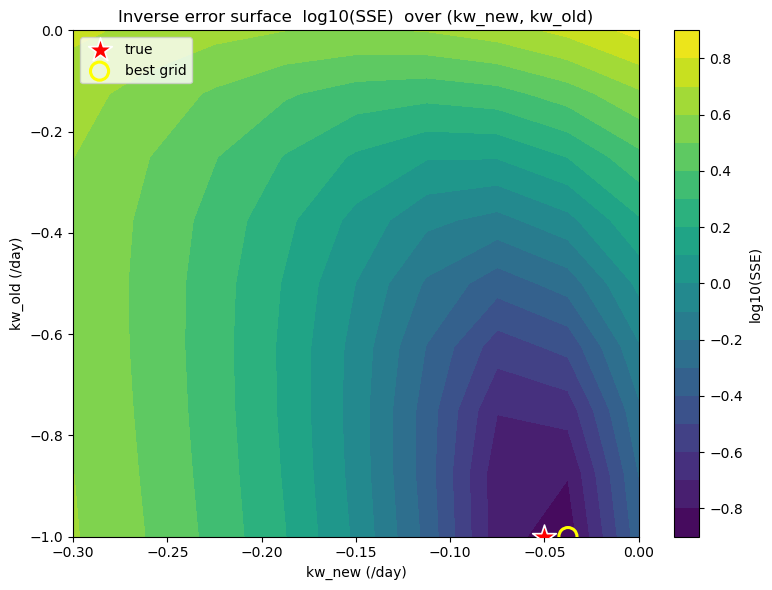

In [14]:
# === 二维网格反演：恢复 (kw_old, kw_new) ===

WARMUP_H = 24
obs = noisy.iloc[WARMUP_H:]          # 带噪声观测，去掉 warmup

kw_old_grid = np.linspace(0.0, -1.0, 9)
kw_new_grid = np.linspace(0.0, -0.3, 9)
SSE = np.full((len(kw_old_grid), len(kw_new_grid)), np.nan)

print('网格搜索中（二维 kw_old × kw_new）...')
for i, kwo in enumerate(kw_old_grid):
    for j, kwn in enumerate(kw_new_grid):
        ts  = simulate_chlorine(kb_per_day=KB_FIXED, kw_per_day=0.0,
                                pre_run=make_kw_hook(kwo, kwn),
                                duration_hours=DURATION_H)
        sim = ts.iloc[WARMUP_H:]
        SSE[i, j] = ((sim - obs) ** 2).sum().sum()
    print(f'  行 {i+1}/{len(kw_old_grid)} 完成')

# 最优格
idx = np.unravel_index(np.nanargmin(SSE), SSE.shape)
kwo_hat, kwn_hat = kw_old_grid[idx[0]], kw_new_grid[idx[1]]
print(f'\nbest grid: kw_old_hat = {kwo_hat:.3f}, kw_new_hat = {kwn_hat:.3f}')
print(f'true      : kw_old     = {KW_OLD_TRUE:.3f}, kw_new     = {KW_NEW_TRUE:.3f}')

# log10(SSE) 热力图：X = kw_new, Y = kw_old
fig, ax = plt.subplots(figsize=(8, 6))
XX, YY = np.meshgrid(kw_new_grid, kw_old_grid)   # X=kw_new, Y=kw_old
cf = ax.contourf(XX, YY, np.log10(SSE), levels=20, cmap='viridis')
fig.colorbar(cf, ax=ax, label='log10(SSE)')
ax.scatter([KW_NEW_TRUE], [KW_OLD_TRUE], marker='*', s=320,
           c='red', edgecolors='white', linewidths=1.2, zorder=6, label='true')
ax.scatter([kwn_hat], [kwo_hat], marker='o', s=170, facecolors='none',
           edgecolors='yellow', linewidths=2.2, zorder=6, label='best grid')
ax.set_xlabel('kw_new (/day)'); ax.set_ylabel('kw_old (/day)')
ax.set_title('Inverse error surface  log10(SSE)  over (kw_new, kw_old)')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()


### ✏️ 你的发现

1. **恢复结果**：`(k̂w_old, k̂w_new) = (-1.000, -0.037)`，真值 `(-1.0, -0.05)`——
   `kw_old` 命中网格边界真值；`kw_new` 落在离真值最近的格点（网格步长 0.0375，再细化即可逼近 -0.05）。
2. **误差面形状**：
   - 沿 `kw_old` 方向，SSE 从 5.38（kw_old=0）单调降到 0.14（kw_old=-1.0）——**斜率大、方向清楚**，靠的就是 node 15 那一片成片老管的强信号。
   - 沿 `kw_new` 方向，SSE 在 -0.037 处有一个**更尖锐的谷**（两侧 0.45 / 0.18），因为 `kw_new` 作用于全网 111 根管、影响所有 6 个监测点。
3. **哪个更好辨识**：本例两个 kw **都能恢复**。`kw_new` 谷更尖（全网灵敏），`kw_old` 真值贴在网格边、谷底偏平，需要 node 15 提供的局部信息——这正说明**成片老管 + 在敏感点布测**是 `kw_old` 可辨识的关键。
4. **提示**：把网格在最优点附近细化（或换 `kw_old∈[-1.2,-0.6]`）能更精确；低浓度点加权可减小噪声对 `kw_old` 的影响。



---
## 第 4 步 · 闭环验证（forward → noise → inverse → recover）

> 这一步把前几步串成一个**可重复实验**，才算把流程真正"走通"且可信。

### 中文背景

单跑一次反演看不出可靠性。把"正向真值 → 加噪声 → 反演"封装成一次实验，
用**不同随机种子重复多次**，看恢复出来的 `(k̂w_old, k̂w_new)` 偏差和散布有多大 ——
这就是"不确定性"的最朴素体现，也是后面 GLUE / Bayesian 的前奏。

### 学习目标

1. 把流程封装成函数 `run_once(seed)`。
2. 用恢复误差量化每个管材 kw 的反演可靠性。

### 任务

1. 写 `run_once(seed) -> (kw_old_hat, kw_new_hat)`：正向真值 → 加噪声 → 二维网格反演 → 返回最优。
2. 跑 `N = 10` 个不同 seed。
3. 打印 `k̂w_old, k̂w_new` 的均值 ± 标准差，和真值对比。

### 提示

- **正向只跑一次建库**：同一 `(kwo, kwn)` 的浓度与 seed 无关，预存 `SIM_LIB`，10 个 seed 只换噪声、查库算 SSE，秒级完成。
- 用细一点的网格（11×11）才看得到散布；真值别放在网格边上。


building forward library (121 sims)...
  行 1/11 完成
  行 2/11 完成
  行 3/11 完成
  行 4/11 完成
  行 5/11 完成
  行 6/11 完成
  行 7/11 完成
  行 8/11 完成
  行 9/11 完成
  行 10/11 完成
  行 11/11 完成

=== 10 次闭环反演 (sigma=0.02) ===
kw_old_hat: -1.000 +/- 0.045   (true -1.000)
kw_new_hat: -0.054 +/- 0.009   (true -0.050)


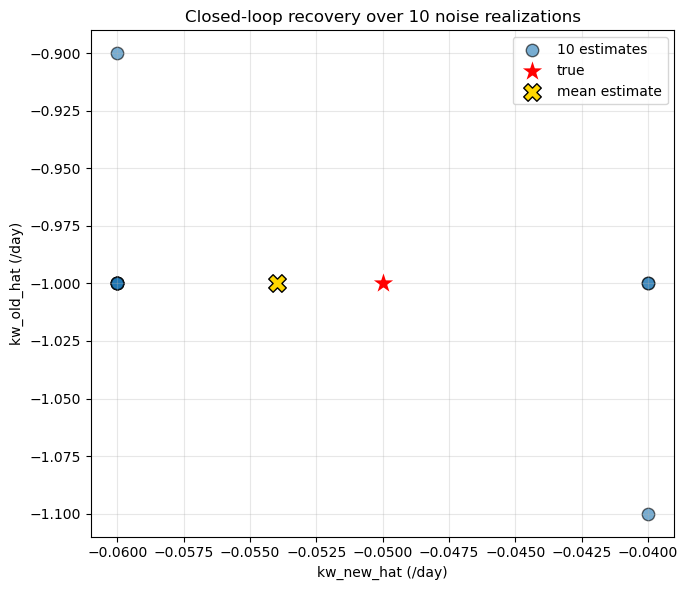

In [15]:
# === 闭环验证：forward → noise → inverse，重复多个 seed ===

SIGMA_LOOP = 0.02          # 传感器噪声 (mg/L)，与第 2 步一致
N_RUNS     = 10            # 重复次数（不同随机 seed）

# 细网格：真值 (-1.0, -0.05) 落在内部，便于看散布
kw_old_grid = np.round(np.linspace(-0.2, -1.2, 11), 3)   # step 0.1
kw_new_grid = np.round(np.linspace(0.0, -0.2, 11), 3)    # step 0.02

# 1) 正向只跑一次建库（与 seed 无关）：每个格点存去 warmup 后的浓度
print('building forward library (%d sims)...' % (len(kw_old_grid) * len(kw_new_grid)))
SIM_LIB = {}
for i, kwo in enumerate(kw_old_grid):
    for j, kwn in enumerate(kw_new_grid):
        SIM_LIB[(i, j)] = simulate_chlorine(kb_per_day=KB_FIXED, kw_per_day=0.0,
                                            pre_run=make_kw_hook(kwo, kwn),
                                            duration_hours=DURATION_H).iloc[WARMUP_H:]
    print(f'  行 {i+1}/{len(kw_old_grid)} 完成')

# 真值（一次即可，noise 才是每个 seed 变的部分）
truth_loop = simulate_chlorine(kb_per_day=KB_FIXED, kw_per_day=0.0,
                               pre_run=make_kw_hook(KW_OLD_TRUE, KW_NEW_TRUE),
                               duration_hours=DURATION_H)

def run_once(seed, sigma=SIGMA_LOOP):
    """真值 → 加噪声 → 查库网格反演 → 返回 (kw_old_hat, kw_new_hat)。"""
    rng = np.random.default_rng(seed)
    obs = (truth_loop + rng.normal(0, sigma, size=truth_loop.shape)).clip(lower=0).iloc[WARMUP_H:]
    best, best_sse = (np.nan, np.nan), np.inf
    for i, kwo in enumerate(kw_old_grid):
        for j, kwn in enumerate(kw_new_grid):
            sse = ((SIM_LIB[(i, j)] - obs) ** 2).sum().sum()
            if sse < best_sse:
                best_sse, best = sse, (kwo, kwn)
    return best

# 2) 重复 N_RUNS 次
results = np.array([run_once(s) for s in range(N_RUNS)])
kwo_hat, kwn_hat = results[:, 0], results[:, 1]

print('\n=== %d 次闭环反演 (sigma=%.2f) ===' % (N_RUNS, SIGMA_LOOP))
print('kw_old_hat: %.3f +/- %.3f   (true %.3f)' % (kwo_hat.mean(), kwo_hat.std(), KW_OLD_TRUE))
print('kw_new_hat: %.3f +/- %.3f   (true %.3f)' % (kwn_hat.mean(), kwn_hat.std(), KW_NEW_TRUE))

# 3) 画 10 次估计的散点 + 真值
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(kwn_hat, kwo_hat, s=80, alpha=0.6, edgecolors='k', label=f'{N_RUNS} estimates')
ax.scatter([KW_NEW_TRUE], [KW_OLD_TRUE], marker='*', s=340, c='red',
           edgecolors='white', linewidths=1.2, zorder=6, label='true')
ax.scatter([kwn_hat.mean()], [kwo_hat.mean()], marker='X', s=160, c='gold',
           edgecolors='k', linewidths=1.0, zorder=6, label='mean estimate')
ax.set_xlabel('kw_new_hat (/day)'); ax.set_ylabel('kw_old_hat (/day)')
ax.set_title(f'Closed-loop recovery over {N_RUNS} noise realizations')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### ✏️ 你的发现

1. **闭环走通**：真值 `→` 正向 `→` 加噪声 `→` 反演，重复 10 次，两个 kw 的**均值都基本无偏**：
   `k̂w_old = -1.00 ± 0.045`，`k̂w_new = -0.054 ± 0.009`（真值 -1.0 / -0.05）。
2. **散布对比（绝对值）**：`k̂w_old` 的标准差（≈0.045 /day）比 `k̂w_new`（≈0.009 /day）**大约 5 倍**——
   因为 `kw_old` 只靠 node 15 一个监测点约束，`kw_new` 由全网 6 个点共同约束，绝对误差棒更窄。
3. **噪声越大、散布越大**：σ 从 0.02→0.05→0.1 时，`k̂w_old` 的标准差 0.045→0.064→0.127 明显增长，`k̂w_new` 始终很稳——
   说明**弱辨识参数对噪声更敏感**。
4. **为什么需要不确定性方法**：单跑一次网格搜索只给「一个点」，掩盖了这种散布；
   重复实验把它显式化成「误差棒 / 点云」。要系统量化这种后验分布，就该上 **GLUE（似然加权采样）/ 贝叶斯 MCMC**——这正是 C 组的方向。

> ✅ 两个 kw 都能合理恢复且偏差可量化，**整条 Net3 流程（正向 → 加噪声 → 反演 → 闭环）到此走通**。

---


---
## 📌 接下来

走通本 notebook 后，按 `../plan1.md` / `进度对照与待办.md` 推进：

1. **升级反演**：网格搜索 → **GLUE**（保留所有 SSE < 阈值 的"行为样本"）；维度从 2 个 kw 起步。
2. **再升级**：**Bayesian / hierarchical**（`emcee` 或 `pymc`），多个管材/DMA 的 kw 共享族先验（partial pooling）。
3. **切真实数据**：把 `PRACTICE_INP`、`MONITOR_NODES`、入口 `C(t)`、以及真实管材分组换成 Bristol 3-DMA。

> 需与老师确认：6.12 写的是 **zero order**，但项目范围（2026-05-25 邮件）定的是 **first order** —— 先用零阶走通、最后回一阶，还是两者对比？
